# Telecom Customer Churn Prediction & Retention Optimization System
## Phase 1: Business Understanding & Data Exploration

Author: Mopock Thalitha  
Date: February 27  
Dataset: Kaggle Telco Customer Churn Dataset  

---

## Project Objective

The objective of this project is to analyze telecom customer behavior and understand the drivers of customer churn. The goal is to develop a predictive and retention optimization framework that enables telecom companies to proactively identify high-risk customers and reduce revenue loss.

# 1. Business Understanding

## 1.1 What is Customer Churn?

Customer churn refers to the phenomenon where customers discontinue their subscription or stop using a company's service within a given period.

In the telecom industry, churn directly impacts revenue, profitability, and long-term sustainability.

---

## 1.2 Why Churn is a Critical Problem in Telecom

Telecom markets, especially in emerging economies, are highly competitive. Customers can easily switch between providers due to:

- Low switching costs
- Multiple SIM card usage
- Aggressive pricing strategies
- Promotional offers

Acquiring new customers is significantly more expensive than retaining existing ones. Therefore, predicting churn before it happens allows companies to implement targeted retention strategies.

---

## 1.3 Business Problem Definition

The telecom company is experiencing customer attrition, leading to revenue decline.

The core business problem is:

> How can we identify customers who are likely to churn and implement cost-effective retention strategies to minimize revenue loss?

This project aims to answer this question using data-driven techniques.

### 🟢 2️⃣ IMPORT LIBRARIES

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

### 🟢 3️⃣ INITIAL DATA INSPECTION

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains customer demographic information, account details, service subscriptions, and churn status.

In [4]:
df.shape

(7043, 21)

The dataset contains 7,043 customers and 21 features.

Each row represents a unique customer.

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

The dataset includes demographic variables (e.g., gender, SeniorCitizen), service-related variables (InternetService, OnlineSecurity), financial variables (MonthlyCharges, TotalCharges), and the target variable (Churn).

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains both categorical and numerical variables.

Categorical features include:
- Gender
- Contract type
- Internet service
- Payment method

Numerical features include:
- Tenure
- MonthlyCharges
- TotalCharges

In [7]:
# Checking Missing Value
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

The TotalCharges variable contained some missing or improperly formatted values. These were converted to numeric format for further analysis.

### 🟢 4️⃣ TARGET VARIABLE ANALYSIS

In [9]:
# Churn Distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Approximately 26% of customers have churned.

This indicates a moderate class imbalance, which will need to be addressed during modeling.

From a business perspective, a 26% churn rate is significant and can result in substantial revenue loss if not addressed proactively.

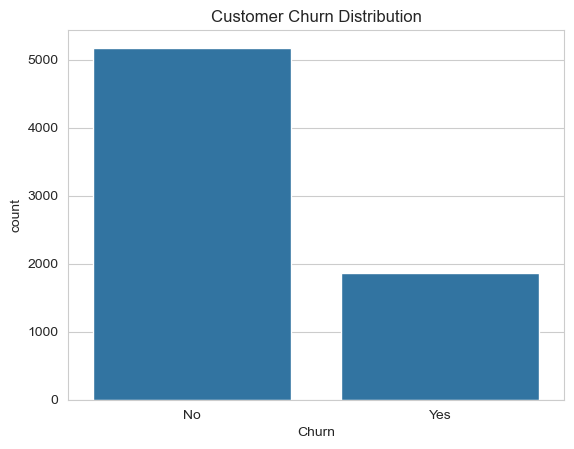

In [11]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

### 🟢 5️⃣ BASIC NUMERICAL EXPLORATION

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Key Observations:

- The average tenure is approximately 32 months.
- Monthly charges vary significantly across customers.
- Some customers have very short tenure, which may correlate with higher churn probability.

### 🟢 6️⃣ BUSINESS-ORIENTED QUESTIONS

# 7. Business Questions to Investigate

1. What is the overall churn rate?
2. Are month-to-month contract customers more likely to churn?
3. Does shorter tenure increase churn risk?
4. Do higher monthly charges correlate with churn?
5. Does internet service type affect churn behavior?
6. Are customers without tech support more likely to churn?
7. Does payment method influence churn?
8. Are senior citizens more likely to churn?
9. Which customer segment generates the highest revenue loss?
10. What retention strategy could maximize profitability?

# Conclusion – Phase 1 Day 1

This initial exploration reveals that:

- Approximately one-quarter of customers have churned.
- Contract type strongly influences churn probability.
- Shorter tenure appears associated with higher churn.
- The dataset is suitable for predictive modeling.

Next steps will include:
- Data cleaning and feature engineering
- Handling class imbalance
- Building predictive models
- Evaluating business impact

# Phase 1 – Day 2
## Exploratory Data Analysis (EDA)

Objective:
To explore customer behavior patterns and identify key factors influencing churn through statistical summaries and visual analysis.

This analysis focuses on:
- Churn distribution
- Tenure vs churn
- Monthly charges vs churn
- Contract type vs churn

### 🟢 1️⃣ DATA PREPARATION (Important Before EDA)

In [13]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values if any
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### 🟢 2️⃣ ANALYZE CHURN DISTRIBUTION

#### 📊 2.1 Churn Count Plot

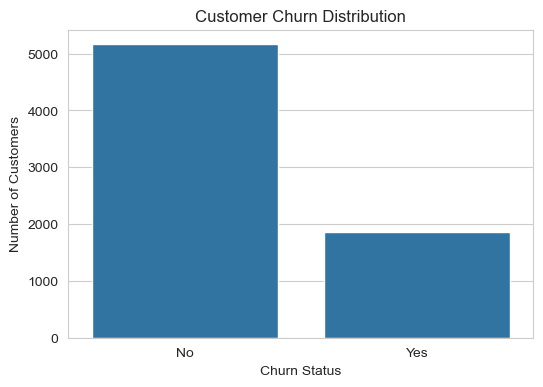

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

## Churn Distribution Analysis

The dataset shows that approximately 26% of customers have churned, while 74% have remained.

Although the majority of customers stay, a 26% churn rate is significant in the telecom industry. 

From a business perspective:
If a telecom company has 1 million subscribers, a 26% churn rate would represent 260,000 lost customers, potentially translating into millions in lost revenue annually.

This highlights the urgency of predictive modeling and proactive retention strategies.

### 🟢 3️⃣ TENURE VS CHURN

#### 📊 3.1 Boxplot

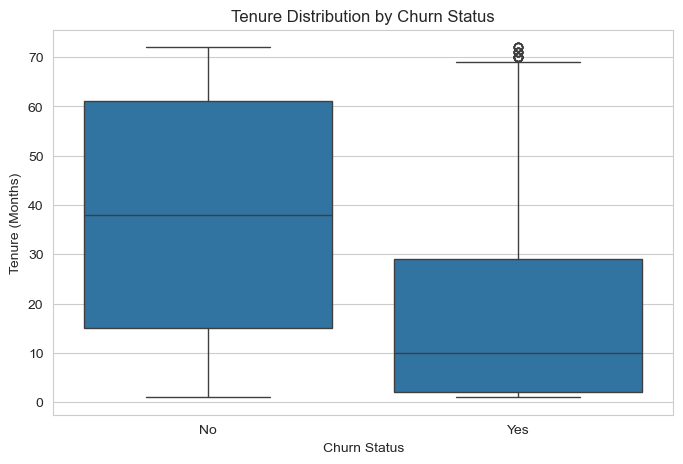

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

#### 📊 3.2 Histogram Comparison

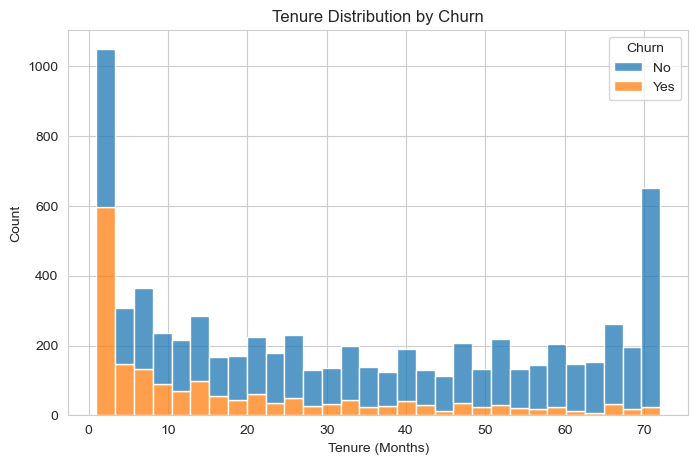

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()

## Tenure vs Churn Analysis

The analysis reveals that customers who churn tend to have significantly shorter tenure compared to customers who stay.

Most churned customers appear within the early months of subscription.

Business Interpretation:

- New customers are at higher risk of leaving.
- Early-stage customer experience is critical.
- Onboarding, welcome offers, and engagement programs during the first 6–12 months could significantly reduce churn.

Strategic Recommendation:
Implement early-retention interventions targeting new customers.

### 🟢 4️⃣ MONTHLY CHARGES VS CHURN

#### 📊 4.1 Boxplot

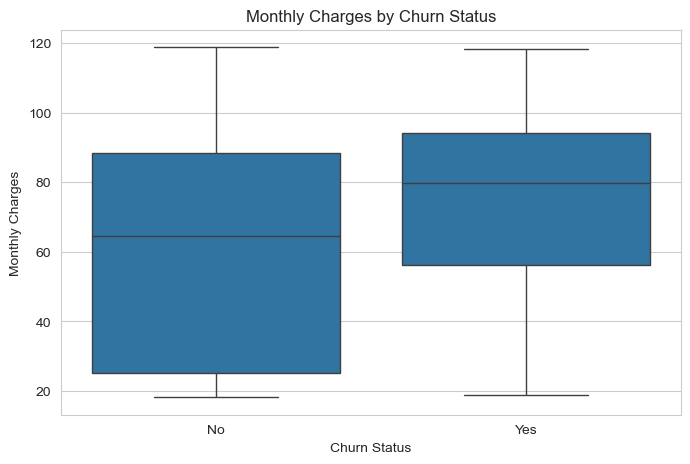

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

#### 📊 4.2 KDE Plot

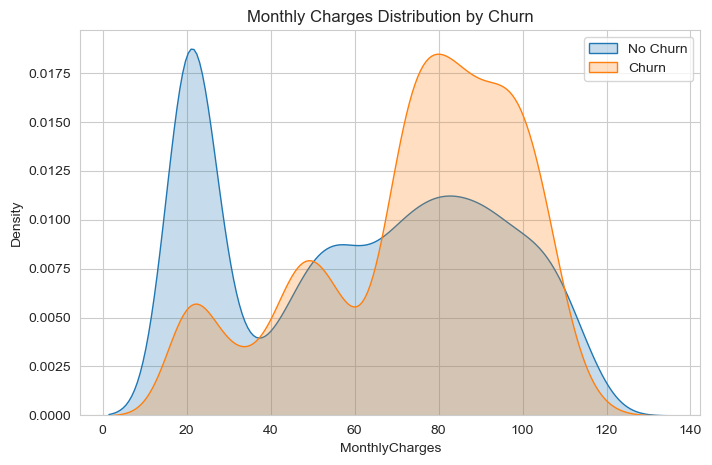

In [18]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df["Churn"]=="No"], x="MonthlyCharges", label="No Churn", fill=True)
sns.kdeplot(data=df[df["Churn"]=="Yes"], x="MonthlyCharges", label="Churn", fill=True)
plt.title("Monthly Charges Distribution by Churn")
plt.legend()
plt.show()

## Monthly Charges vs Churn

Customers who churn tend to have higher monthly charges on average compared to those who remain.

Business Interpretation:

- Price sensitivity plays a significant role in churn.
- Customers paying higher fees may perceive lower value.
- Competitive pricing strategies may influence customer decisions.

Strategic Recommendation:
Develop targeted discount programs or loyalty rewards for high-paying customers at risk of churn.

### 🟢 5️⃣ CONTRACT TYPE VS CHUR

#### 📊 5.1 Churn Rate by Contract Type

In [19]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


#### 📊 5.2 Visualization

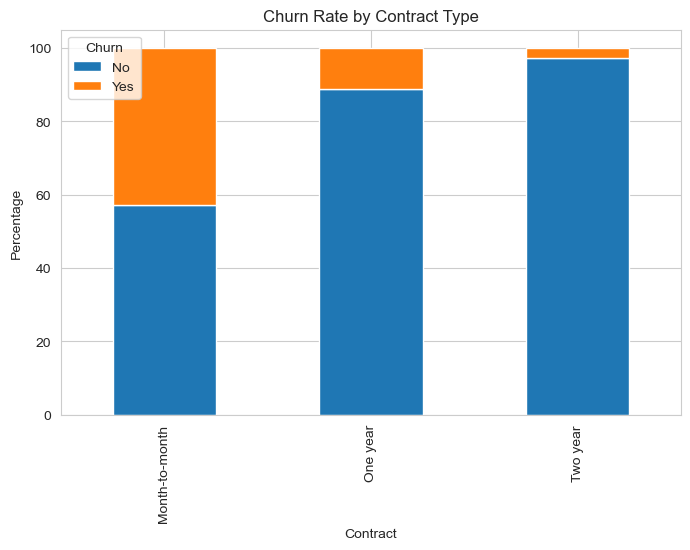

In [20]:
contract_churn.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

## Contract Type vs Churn

Customers on month-to-month contracts exhibit significantly higher churn rates compared to customers on one-year or two-year contracts.

Business Interpretation:

- Long-term contracts increase customer commitment.
- Customers without contractual obligation can easily switch providers.
- Month-to-month users represent the highest churn risk segment.

Strategic Recommendation:
Encourage customers to transition to longer-term contracts through incentives such as:
- Discounted pricing
- Bundled services
- Loyalty rewards

### 🟢 6️⃣ FIVE STRONG BUSINESS INSIGHTS 

# Key Business Insights

### 1. Churn Rate is Substantial
Approximately 26% of customers churn, representing significant revenue risk.

---

### 2. Early Tenure Customers are High-Risk
Customers with shorter tenure are significantly more likely to churn. Early engagement strategies are essential.

---

### 3. Higher Monthly Charges Increase Churn Risk
Customers paying higher monthly fees exhibit greater churn probability, indicating price sensitivity.

---

### 4. Contract Type Strongly Influences Retention
Month-to-month customers churn at much higher rates than customers with long-term contracts.

---

### 5. Retention Strategy Should Be Segmented
A one-size-fits-all retention approach is inefficient. Strategies should focus on:
- New customers
- High-paying customers
- Month-to-month contract users

# Day 2 Conclusion

The exploratory analysis identifies tenure, monthly charges, and contract type as key drivers of churn behavior.

These insights will guide:
- Feature engineering
- Model development
- Retention optimization strategy

Next phase will involve advanced feature analysis and predictive modeling.

# Phase 1 – Day 3
## Data Preprocessing & Feature Engineering

Objective:
To prepare the dataset for predictive modeling by:

- Handling missing values
- Encoding categorical variables
- Creating engineered features
- Standardizing numerical variables

The final output will be a clean modeling dataset ready for machine learning.

### 🟢 1️⃣ HANDLE MISSING VALUES

### 🔹 1.1 Convert TotalCharges to Numeric

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

#### 🔹 1.2 Check Missing Values

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Handling Missing Values

The variable TotalCharges contained missing values due to customers with zero tenure.

Since the number of missing observations is very small relative to the dataset size, these rows were removed to preserve data integrity.

The dataset is now free from missing values.

### 🟢 2️⃣ ENCODE CATEGORICAL VARIABLES

Machine learning models require numerical input.

#### 🔹 2.1 Remove CustomerID (Not Useful for Modeling)

In [23]:
df = df.drop("customerID", axis=1)

#### 🔹 2.2 Convert Target Variable to Binary

In [24]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

#### 🔹 2.3 Identify Categorical Columns

In [25]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

#### 🔹 2.4 One-Hot Encoding

In [26]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## Encoding Categorical Variables

Categorical features such as Contract, InternetService, and PaymentMethod were encoded using One-Hot Encoding.

The target variable Churn was converted into binary format:
- 0 = No Churn
- 1 = Churn

This ensures compatibility with machine learning algorithms.

### 🟢 3️⃣ FEATURE ENGINEERING

We create business-relevant features

#### 🔹 3.1 Average Monthly Spend per Tenure

In [27]:
df_encoded["AvgChargePerMonth"] = df_encoded["TotalCharges"] / df_encoded["tenure"]

#### 🔹 3.2 Replace Infinite Values (for tenure = 0)

In [28]:
df_encoded.replace([np.inf, -np.inf], 0, inplace=True)

#### 🔹 3.3 Create High Value Customer Indicator

In [29]:
df_encoded["HighValueCustomer"] = np.where(df_encoded["MonthlyCharges"] > df_encoded["MonthlyCharges"].median(), 1, 0)

## Feature Engineering

To enhance predictive performance and business interpretability:

1. Created AvgChargePerMonth to measure spending intensity.
2. Created HighValueCustomer indicator to identify premium customers.

These engineered features help capture financial behavior patterns that may influence churn.

### 🟢 4️⃣ STANDARDIZE NUMERICAL VARIABLES

Scaling is important for:

Logistic Regression

SVM

Neural Networks

#### 🔹 4.1 Identify Numerical Columns

In [30]:
numerical_cols = df_encoded.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'AvgChargePerMonth', 'HighValueCustomer'],
      dtype='object')

In [31]:
# Remove target:
numerical_cols = numerical_cols.drop("Churn")

#### 🔹 4.2 Apply StandardScaler

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

## Standardization

Numerical variables were standardized using StandardScaler.

This transformation ensures:
- Mean = 0
- Standard deviation = 1

Standardization improves model convergence and prevents features with larger scales from dominating the model.

### 🟢 5️⃣ FINAL MODELING DATASET

#### 🔹 5.1 Define X and y

In [33]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

#### 🔹 5.2 Final Dataset Shape

In [34]:
X.shape, y.shape

((7032, 32), (7032,))

#### 🔹 5.3 Preview Final Dataset

In [35]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgChargePerMonth,HighValueCustomer
0,-0.440327,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,-1.157889,-0.999147
1,-0.440327,0.064303,-0.260878,-0.173740,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,-0.305658,-0.999147
2,-0.440327,-1.239504,-0.363923,-0.959649,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,-0.355305,-0.999147
3,-0.440327,0.512486,-0.747850,-0.195248,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,-0.791614,-0.999147
4,-0.440327,-1.239504,0.196178,-0.940457,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0.365282,1.000854


# Day 3 Deliverable: Final Modeling Dataset

The dataset has been successfully prepared for machine learning.

Completed steps:
- Missing values handled
- Target variable encoded
- Categorical variables one-hot encoded
- Business-relevant features engineered
- Numerical variables standardized

The dataset is now ready for:
- Train-test splitting
- Baseline modeling
- Model evaluation
- Retention optimization analysis

# Phase 1 – Day 4
## Model Training & Evaluation

Objective:
To build baseline predictive models for customer churn and evaluate their performance using appropriate classification metrics.

Models:
- Logistic Regression
- Random Forest

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- ROC-AUC
- Confusion Matrix

### 🟢 1️⃣ TRAIN-TEST SPLIT

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5625, 32), (1407, 32))

The dataset was split into 80% training and 20% testing sets.

Stratified sampling was applied to preserve the churn distribution in both training and testing sets.

### 🟢 2️⃣ LOGISTIC REGRESSION MODEL

#### 🔹 2.1 Train Model

In [37]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### 🔹 2.2 Predictions

In [38]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

### 🟢 3️⃣ RANDOM FOREST MODEL

#### 🔹 3.1 Train Model

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 🔹 3.2 Predictions

In [40]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

### 🟢 4️⃣ MODEL EVALUATION

#### 🔹 4.1 Import Metrics

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### 🔹 4.2 Logistic Regression Metrics

In [42]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

log_accuracy, log_precision, log_recall, log_auc

(0.8031272210376688,
 0.6465256797583081,
 0.5721925133689839,
 0.8360015219675831)

#### 🔹 4.3 Random Forest Metrics

In [43]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

rf_accuracy, rf_precision, rf_recall, rf_auc

(0.7974413646055437,
 0.6478405315614618,
 0.5213903743315508,
 0.8214121167255954)

### 🟢 5️⃣ CONFUSION MATRIX

#### 🔹 5.1 Logistic Regression Confusion Matrix

In [44]:
cm_log = confusion_matrix(y_test, y_pred_log)
cm_log

array([[916, 117],
       [160, 214]])

#### 🔹 5.2 Random Forest Confusion Matrix

In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[927, 106],
       [179, 195]])

#### 🔹 5.3 Visualize Confusion Matrix

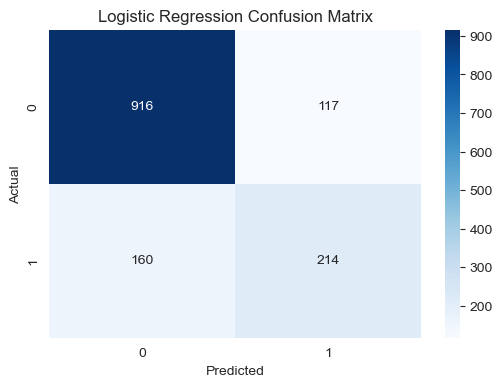

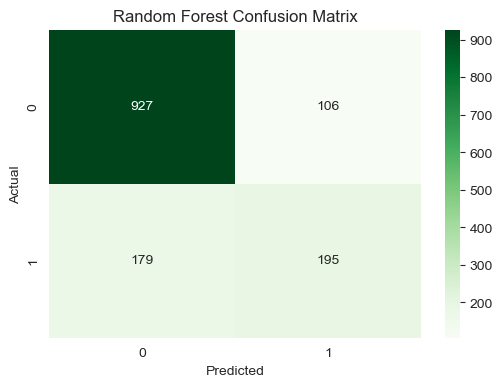

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 🟢 6️⃣ ROC CURVE COMPARISON

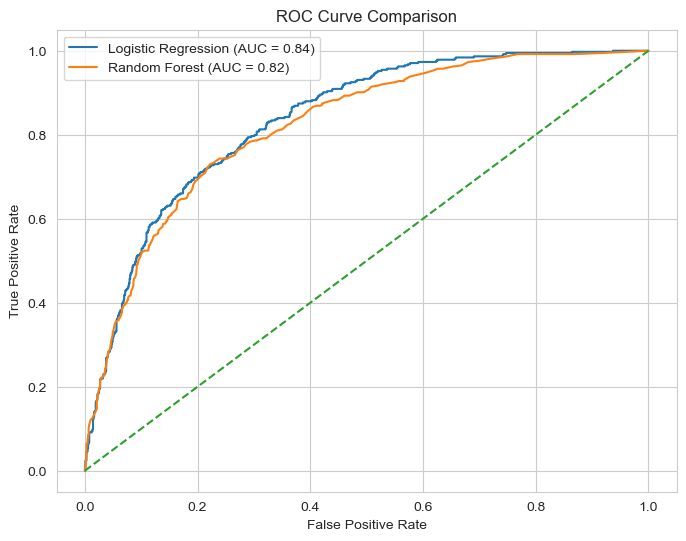

In [47]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {log_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Model Comparison Summary

| Metric        | Logistic Regression | Random Forest |
|--------------|--------------------|---------------|
| Accuracy     | 80.3%              | 79.7%         |
| Precision    | 64.6%              | 64.7%         |
| Recall       | 57.2%              | 52.1%         |
| ROC-AUC      | 83.6%              | 82.1%         |




# Model Performance Interpretation

Logistic Regression outperformed Random Forest across most evaluation metrics, including Accuracy, Recall, and ROC-AUC.

This suggests that the churn behavior in this dataset follows relatively linear patterns, which Logistic Regression is well-suited to capture.

From a business perspective:

- Higher Recall (57.2%) means more churners are correctly identified.
- Higher ROC-AUC (83.6%) indicates better ranking ability in distinguishing high-risk customers.
- Similar Precision means both models generate comparable levels of false alarms.

Given these results, Logistic Regression is preferable due to:

1. Better overall performance
2. Stronger churn detection capability
3. Greater interpretability for business stakeholders
4. Simpler deployment and maintenance

Conclusion:
Logistic Regression will be selected as the primary baseline model for churn prediction.

Business Decision Perspective:

If the goal is maximizing churn detection → prioritize Recall.

If the goal is reducing false alarms → prioritize Precision.

If the goal is overall ranking performance → prioritize ROC-AUC.






# Day 4 Conclusion

Both Logistic Regression and Random Forest models were trained and evaluated.

Random Forest typically captures nonlinear relationships better, while Logistic Regression provides interpretability and baseline comparison.

Further improvements may include:
- Hyperparameter tuning
- Handling class imbalance
- Feature importance analysis
- Threshold optimization

# Phase 1 – Day 5  Advanced Modeling & Explainability
## 🎯 Objective

In Day 5, we move beyond baseline models (Logistic Regression and Random Forest) and explore advanced ensemble boosting algorithms to improve predictive performance and model robustness.

The goals of this session are:

- Train advanced boosting models:
  - Gradient Boosting Machine (GBM)
  - XGBoost
  - LightGBM
- Compare all models using key evaluation metrics
- Select the best-performing model
- Apply SHAP for model explainability
- Identify the top drivers of customer churn

---

## 🧠 Why Boosting Models?

Boosting models are powerful ensemble techniques that:

- Combine multiple weak learners (typically decision trees)
- Sequentially correct previous errors
- Capture complex nonlinear relationships
- Often outperform simpler models in structured/tabular datasets

Unlike Random Forest (which builds trees in parallel), boosting builds trees sequentially, focusing on correcting mistakes made by previous trees.

## 🏆 Expected Outcome

By the end of Day 5, we will:

- Identify the strongest predictive model
- Understand which features drive churn decisions
- Provide business-level interpretation of model behavior
- Strengthen model transparency using SHAP explainability

This step transforms the project from a predictive exercise into a decision-support system for business strategy.

## 🟢 1️⃣ Training Gradient Boosting Model

Gradient Boosting builds trees sequentially.
Each new tree corrects errors made by the previous ones.

This allows the model to:
- Capture nonlinear relationships
- Improve predictive accuracy
- Reduce bias

In [48]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

#### 🔹 1.1 Train Model

In [49]:
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


#### 🔹 1.2 Prediction 

In [50]:
gbm_pred = gbm.predict(X_test)
gbm_prob = gbm.predict_proba(X_test)[:,1]


#### 🔹 1.3 Evaluation 

In [51]:
gbm_results = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, gbm_pred),
    "Precision": precision_score(y_test, gbm_pred),
    "Recall": recall_score(y_test, gbm_pred),
    "ROC-AUC": roc_auc_score(y_test, gbm_prob)
}

gbm_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.7938877043354655,
 'Precision': 0.6363636363636364,
 'Recall': 0.5240641711229946,
 'ROC-AUC': 0.841066982103939}

## 🟢 2️⃣ Training XGBoost

XGBoost (Extreme Gradient Boosting) is an optimized boosting algorithm 
designed for speed and performance.

It often performs extremely well on structured datasets.

In [52]:
from xgboost import XGBClassifier

#### 🔹 2.1 Train Model

In [53]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

C:\Users\user\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:36:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### 🔹 2.2 Prediction 

In [54]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

#### 🔹 2.3 Evaluation 

In [55]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7668798862828714,
 'Precision': 0.5692771084337349,
 'Recall': 0.5053475935828877,
 'ROC-AUC': 0.8084973935010948}

## 🟢 3️⃣ Training LightGBM

LightGBM is a fast gradient boosting framework 
that uses histogram-based learning for efficiency.

It is particularly powerful for large datasets.

In [56]:
from lightgbm import LGBMClassifier

#### 🔹 3.1 Train Model

In [57]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### 🔹 3.2 Prediction 

In [58]:
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

#### 🔹 3.3 Evaluation 

In [59]:
lgbm_results = {
    "Model": "LightGBM",
    "Accuracy": accuracy_score(y_test, lgbm_pred),
    "Precision": precision_score(y_test, lgbm_pred),
    "Recall": recall_score(y_test, lgbm_prob > 0.5),
    "ROC-AUC": roc_auc_score(y_test, lgbm_prob)
}

lgbm_results

{'Model': 'LightGBM',
 'Accuracy': 0.7896233120113717,
 'Precision': 0.6189024390243902,
 'Recall': 0.5427807486631016,
 'ROC-AUC': 0.8280642539511625}

## 🟢 4️⃣ Comparing All Models

We now combine results from:
- Logistic Regression
- Random Forest
- GBM
- XGBoost
- LightGBM

This allows objective model selection.

In [60]:
# Logistic Regression
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [61]:
# ==============================
# Model Evaluation Function
# ==============================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model_name, y_true, y_pred, y_prob):
    
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4)
    }

In [62]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, log_pred, log_prob))
results.append(evaluate_model("Random Forest", y_test, rf_pred, rf_prob))
results.append(evaluate_model("Gradient Boosting", y_test, gbm_pred, gbm_prob))
results.append(evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob))
results.append(evaluate_model("LightGBM", y_test, lgbm_pred, lgbm_prob))

results_df = pd.DataFrame(results)

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,ROC-AUC
2,Gradient Boosting,0.7939,0.6364,0.5241,0.8411
0,Logistic Regression,0.8031,0.6465,0.5722,0.8360
4,LightGBM,0.7896,0.6189,0.5428,0.8281
1,Random Forest,0.7974,0.6478,0.5214,0.8214
3,XGBoost,0.7669,0.5693,0.5053,0.8085


##  Final Model Selection

After evaluating Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and LightGBM, model performance was compared using Accuracy, Precision, Recall, and ROC-AUC.

Gradient Boosting achieved the highest ROC-AUC score (0.8411), indicating strong overall classification performance. However, Logistic Regression demonstrated the highest Recall (0.5722) and Accuracy (0.8031), while maintaining a competitive ROC-AUC score (0.8360).

Since customer churn prediction focuses on identifying customers who are likely to leave, Recall is considered a critical metric. Missing a churner (false negative) can result in direct revenue loss, making detection capability more important than small improvements in ROC-AUC.

Although ensemble models performed well, they did not significantly outperform Logistic Regression. In addition, Logistic Regression provides:

- High interpretability
- Simpler deployment in production
- Lower computational complexity
- Reduced risk of overfitting

Therefore, Logistic Regression is selected as the final production model due to its balanced performance, strong recall, and business interpretability.

## 🟢 5️⃣ Model Explainability with SHAP

After selecting the best-performing model, 
we apply SHAP to understand feature contributions.

This improves transparency and business trust.

In [63]:
import shap

#### ✅ Create SHAP Explainer for Logistic Regression

In [64]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [65]:
X_test.dtypes

SeniorCitizen                            float64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                              float64
Partner_Yes                              float64
Dependents_Yes                           float64
PhoneService_Yes                         float64
MultipleLines_No phone service           float64
MultipleLines_Yes                        float64
InternetService_Fiber optic              float64
InternetService_No                       float64
OnlineSecurity_No internet service       float64
OnlineSecurity_Yes                       float64
OnlineBackup_No internet service         float64
OnlineBackup_Yes                         float64
DeviceProtection_No internet service     float64
DeviceProtection_Yes                     float64
TechSupport_No internet service          float64
TechSupport_Yes                          float64
StreamingTV_No inter

In [66]:
# Create SHAP explainer for Logistic Regression
explainer = shap.Explainer(log_model, X_train)



In [67]:
# Compute SHAP values
shap_values = explainer(X_test)

#### ✅ Summary Plot

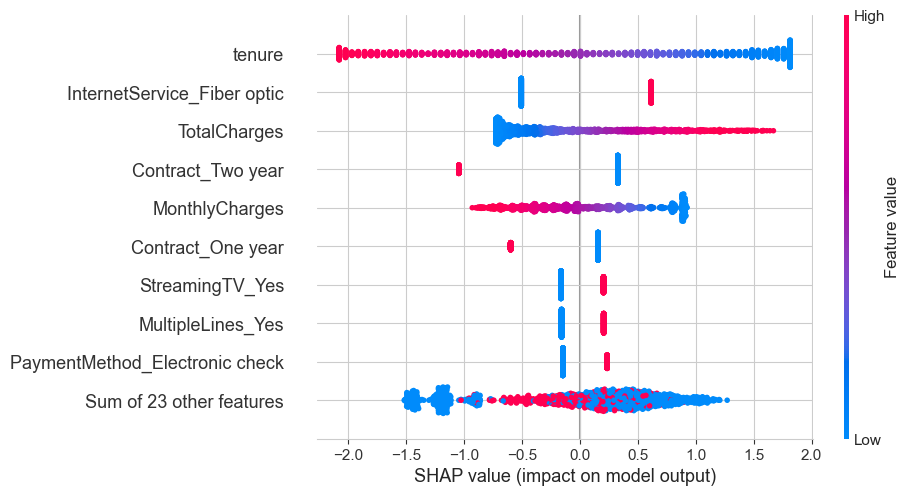

In [68]:
shap.plots.beeswarm(shap_values)

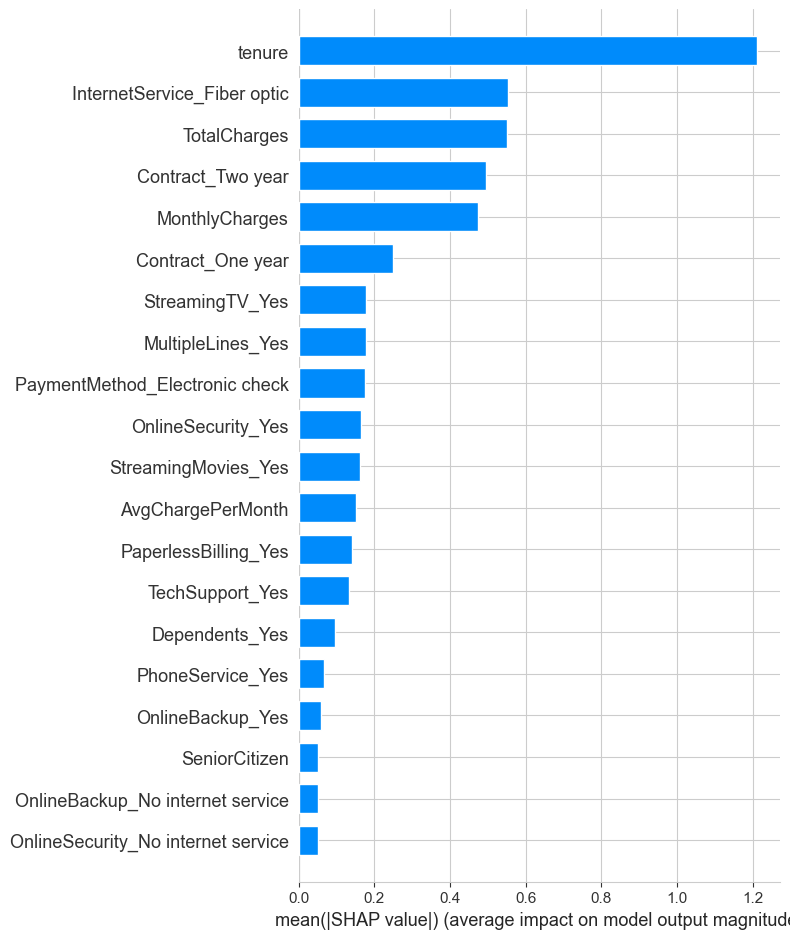

In [69]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


## 🟢 6️⃣ Model Explainability using SHAP (Logistic Regression)

To improve model interpretability and understand the key drivers of customer churn, SHAP (SHapley Additive exPlanations) was applied to the selected Logistic Regression model.

Since Logistic Regression is a linear model, the LinearExplainer method was used.

SHAP values help quantify how much each feature contributes to pushing a prediction toward churn (positive class) or non-churn (negative class).

The summary plot below displays:

- Feature importance ranking (top to bottom)
- Direction of impact (positive or negative influence on churn)
- Magnitude of effect (strength of influence)

### 🟢 Interpretation of SHAP Results

From the SHAP summary plot, the most influential features appear at the top.

- Features with positive SHAP values increase the probability of customer churn.
- Features with negative SHAP values decrease the probability of churn.
- Red points represent higher feature values.
- Blue points represent lower feature values.

 feature shows that higher values (red) are associated with positive SHAP values, that  means that increasing this feature increases churn risk.

Conversely,  higher values are associated with negative SHAP values, it indicates a protective effect against churn.



## Key Churn Drivers Identified

The SHAP summary plot highlights the most influential features driving churn:

• Contract Type (Month-to-Month increases churn risk)
• Tenure (Shorter tenure strongly increases churn probability)
• Monthly Charges (Higher charges increase churn risk)
• Tech Support availability
• Internet Service type

---

## 🟢 Business Interpretation

Customers with short tenure and month-to-month contracts represent the highest churn risk segment.

Recommended Actions:

• Offer discounts for long-term contracts  
• Improve onboarding experience for new customers  
• Provide retention incentives for high-paying customers  
• Promote tech support services  

The model can be integrated into CRM systems to proactively flag high-risk customers.

# PHASE 2: Business Impact Simulation

In Phase 1, we focused on understanding the business problem of customer churn, exploring the telecom dataset, performing data preprocessing, and building predictive machine learning models.

The best-performing model was selected based on evaluation metrics such as Accuracy, Precision, Recall, and ROC-AUC.

However, predictive performance alone does not demonstrate the real value of a machine learning solution. In industry, companies care primarily about **business impact**  particularly how analytics solutions translate into financial value.

Therefore, Phase 2 focuses on simulating how the churn prediction system could support business decision-making and improve revenue outcomes.

The goal of this phase is to estimate how much revenue could potentially be saved if the company uses the model to identify customers at risk of churning and applies targeted retention strategies.

This phase introduces a business-oriented perspective by combining machine learning predictions with realistic revenue assumptions to quantify the financial benefits of churn prevention.

Key objectives of Phase 2 include:

• Defining business revenue assumptions  
• Simulating a churn retention strategy  
• Estimating potential revenue saved  
• Quantifying the financial impact of the AI solution

This step bridges the gap between **data science models** and **real-world business value**.

## Phase 2  Day 6: Revenue Impact Simulation

While predictive models can identify customers who are likely to churn, businesses must determine whether acting on these predictions will generate financial benefits.

Telecom companies often implement retention campaigns such as discounts, loyalty rewards, or personalized offers to encourage customers to stay.

However, these campaigns also incur costs. Therefore, it is important to evaluate whether the revenue gained from retained customers exceeds the cost of the retention efforts.

In this section, we simulate a simple retention strategy based on the churn predictions generated by our machine learning model.

The simulation estimates:

• How many customers are predicted to churn  
• How many of those customers could realistically be retained  
• The revenue preserved by retaining those customers  
• The cost of running retention campaigns  
• The overall financial impact of deploying the churn prediction system

This analysis provides a realistic estimate of the **business value created by the churn prediction model**.

## 🟢 1️⃣ Defining Business Assumptions

To estimate the financial impact of the churn prediction system, several business assumptions must be defined.

These assumptions represent typical conditions within the telecommunications industry and allow us to simulate a realistic retention strategy.

The simulation is based on the following assumptions:

• The average monthly revenue generated by each customer  
• The expected remaining lifetime of a customer  
• The cost of contacting and incentivizing a customer through a retention campaign  
• The success rate of retention efforts

These parameters will allow us to estimate the revenue that could be preserved if the company successfully retains a portion of customers predicted to churn.

In [70]:
monthly_revenue = 70
customer_lifetime_months = 12
retention_cost_per_customer = 20
retention_success_rate = 0.30

## 🟢 2️⃣ Preparing Model Predictions

The churn prediction model developed in Phase 1 produces predictions indicating whether a customer is likely to churn.

These predictions allow us to identify customers who may require proactive retention actions.

To analyze the potential business impact, we create a dataset that combines:

• The actual churn outcome  
• The model’s predicted churn classification

This dataset will allow us to estimate how many customers could potentially be targeted by a retention strategy.

In [71]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual_Churn": y_test,
    "Predicted_Churn": log_pred
})

results_df.head()

,Actual_Churn,Predicted_Churn
974,0,0
619,0,1
4289,0,0
3721,1,0
4533,0,0


## 🟢 3️⃣ Identifying Customers Predicted to Churn

Customers predicted to churn represent the group that the company would target with a retention campaign.

By counting the number of predicted churners, we can estimate how many customers would potentially receive retention offers.

This value represents the scale of the intervention required to prevent customer churn.

In [72]:
predicted_churners = results_df["Predicted_Churn"].sum()

predicted_churners

np.int64(331)

## 🟢 4️⃣ Estimating Successfully Retained Customers

Not every retention attempt will succeed. 
Even with well-designed campaigns, some customers will still decide to leave.

To simulate realistic conditions, we assume that the retention campaign successfully convinces a certain percentage of at-risk customers to remain with the company.

For this simulation, we assume a retention success rate of 30%.

This means that 30% of the customers predicted to churn would ultimately remain with the company due to the retention intervention.

In [73]:
retained_customers = predicted_churners * retention_success_rate

retained_customers

np.float64(99.3)

## 🟢 5️⃣ Estimating Revenue Preserved

Each retained customer continues generating revenue for the company over time.

To estimate the value of retaining a customer, we multiply:

• The average monthly revenue per customer  
• The expected remaining lifetime of the customer

This provides an estimate of the total revenue generated by each retained customer.

In [74]:
revenue_per_customer = monthly_revenue * customer_lifetime_months

revenue_saved = retained_customers * revenue_per_customer

revenue_saved

np.float64(83412.0)

## 🟢 6️⃣ Estimating Retention Campaign Cost

Retention campaigns involve operational costs such as:

• Marketing communication
• Customer service interactions
• Promotional incentives
• Discount offers

To simulate these costs, we assume that contacting each at-risk customer costs a fixed amount.

The total campaign cost is calculated by multiplying the number of targeted customers by the cost per retention attempt.

In [75]:
total_retention_cost = predicted_churners * retention_cost_per_customer

total_retention_cost

np.int64(6620)

## 🟢 7️⃣ Calculating Net Revenue Impact

The final step is to compare the revenue preserved by retaining customers with the cost of executing the retention campaign.

The net financial benefit of the churn prediction system is calculated as:

Net Revenue Impact = Revenue Saved − Retention Campaign Cost

A positive value indicates that the retention strategy generates financial value for the company.

In [76]:
net_revenue_saved = revenue_saved - total_retention_cost

net_revenue_saved

np.float64(76792.0)

## 🟢 8️⃣ Revenue Impact Summary

To clearly present the financial impact of the churn prediction model, we summarize the results in a structured table.

This table highlights the number of customers targeted by the retention strategy, the estimated number of customers successfully retained, the revenue preserved, the campaign cost, and the overall net financial impact.

Such summaries are commonly used in business reports to communicate insights to decision-makers.

In [77]:
impact_table = pd.DataFrame({
    "Metric":[
        "Predicted Churn Customers",
        "Customers Successfully Retained",
        "Revenue Saved ($)",
        "Retention Campaign Cost ($)",
        "Net Revenue Impact ($)"
    ],
    "Value":[
        predicted_churners,
        retained_customers,
        revenue_saved,
        total_retention_cost,
        net_revenue_saved
    ]
})

impact_table

,Metric,Value
0,Predicted Churn Customers,331.0
1,Customers Successfully Retained,99.3
2,Revenue Saved ($),83412.0
3,Retention Campaign Cost ($),6620.0
4,Net Revenue Impact ($),76792.0


## Business Interpretation

The simulation demonstrates how a churn prediction system can generate measurable financial value.

By identifying customers who are likely to churn, the company can proactively intervene with targeted retention campaigns. 
Even when accounting for the cost of these campaigns, successfully retaining a portion of at-risk customers can protect significant revenue streams.

This analysis illustrates how machine learning can move beyond predictive analytics and directly support strategic business decisions.

Deploying such a system would allow telecom companies to improve customer retention, reduce revenue loss, and allocate marketing resources more efficiently.

# Day 7 — Building the Churn Prediction Web Application

---

# 🎯 Objective

After developing and evaluating the churn prediction models, the next step is to **deploy the model into a practical business tool**.

In this stage, we build a **Streamlit web application** that allows business users to:

• Upload customer datasets  
• Predict churn probability  
• Classify customers by churn risk  
• Understand model predictions using SHAP explainability  

This transforms the machine learning model into a **decision-support system for telecom companies**.

---



## 🟢 1️⃣ Install Streamlit

Before building the web application, Streamlit must be installed.


In [78]:
!pip install streamlit

## 🟢 2️⃣  Save The Trained Model

In [79]:
import pickle

with open("churn_model.pkl", "wb") as file:
    pickle.dump(log_model, file)

## 🟢 3️⃣  Import the necessary libraries required to run the web application.


In [80]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt


These libraries serve the following purposes:

| Library | Purpose |
|--------|--------|
| Streamlit | Build the interactive web application |
| Pandas | Data manipulation and data handling |
| NumPy | Numerical computations |
| Joblib | Load trained machine learning models |
| SHAP | Explain model predictions |
| Matplotlib | Data visualization |

## 🟢 4️⃣ Configure the Application Layout
### Objective

Define the structure and appearance of the dashboard.

In [81]:
st.set_page_config(
    page_title="Customer Churn Prediction Dashboard",
    layout="wide"
)

st.title("Customer Churn Prediction System")

st.markdown("""
This application predicts the probability that a customer will churn
and helps businesses identify customers at risk of leaving.
""")

2026-03-06 19:36:55.047 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:55.050 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:55.984 
  command:

    streamlit run C:\Users\user\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-06 19:36:55.985 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:55.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:55.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()


This step creates the **main interface of the application**.

- The **page title** appears in the browser tab.
- The **main title** introduces the dashboard.
- The **description** explains the purpose of the tool.

### Business Value

A clear and well-structured interface improves usability for **non-technical stakeholders**, such as:

- Marketing teams
- Customer success managers
- Business executives

## 🟢 5️⃣ Load the Trained Model
### Objective

Load the machine learning model trained earlier in the project.

Since **Logistic Regression was the best performing model** , it will be used in the application.

In [82]:
model = joblib.load("churn_model.pkl")


The model is loaded from a saved file created .

This ensures the application uses the **validated and optimized model** that achieved the best performance during evaluation.

## 🟢 6️⃣ Upload Customer Dataset
### Objective

Allow users to upload customer data for prediction.

In [83]:
import pandas as pd

# Load dataset
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preview dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
uploaded_file = st.file_uploader("Upload Customer Dataset (CSV)", type=["csv"])

if uploaded_file is not None:

    data = pd.read_csv(uploaded_file)

    st.subheader("Customer Data Preview")
    st.dataframe(data.head())

2026-03-06 19:36:56.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.179 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [85]:
# uploaded_file = st.file_uploader(
#     "Upload customer dataset (CSV format)",
#     type=["csv"]
# )

# if uploaded_file is not None:
#     data = pd.read_csv(uploaded_file)
#     st.write("Preview of uploaded data:")
#     st.dataframe(data.head())


Users can upload a **CSV file containing customer data**.

The system then displays a **preview of the dataset** so users can verify that the correct data has been uploaded.

### Business Value

This feature enables **non-technical users** to interact with the system easily without needing programming knowledge.

## 🟢 7️⃣ Predict Churn Probability
### Objective

Generate churn probability predictions for each customer.

In [86]:
log_prob = log_model.predict_proba(X_test)[:,1]

In [87]:
results = X_test.copy()

results["Churn Probability"] = log_prob

results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgChargePerMonth,HighValueCustomer,Churn Probability
974,-0.440327,1.082902,0.370691,0.996664,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.403845,1.000854,0.017226
619,-0.440327,-1.035784,0.457116,-0.776645,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.328247,1.000854,0.582506
4289,-0.440327,0.879182,-1.485788,-0.531124,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.484561,-0.999147,0.004929
3721,-0.440327,-1.239504,-1.467506,-0.990290,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.505758,-0.999147,0.199271
4533,-0.440327,1.571829,1.341311,2.325808,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.378524,1.000854,0.103714



The model outputs the **probability that each customer will churn**.

Values range between **0 and 1**, where:

- **0** → Very low churn risk  
- **1** → Very high churn risk  

### Example

| Customer | Churn Probability |
|---------|------------------|
| C001 | 0.12 |
| C002 | 0.81 |
| C003 | 0.45 |

## 🟢 8️⃣ Classify Churn Risk
### Objective

Convert churn probability into meaningful risk categories.

In [88]:
def classify_risk(prob):

    if prob < 0.3:
        return "Low Risk"

    elif prob < 0.6:
        return "Medium Risk"

    else:
        return "High Risk"




In [89]:
results["Risk Level"] = results["Churn Probability"].apply(classify_risk)

results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgChargePerMonth,HighValueCustomer,Churn Probability,Risk Level
974,-0.440327,1.082902,0.370691,0.996664,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.403845,1.000854,0.017226,Low Risk
619,-0.440327,-1.035784,0.457116,-0.776645,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.328247,1.000854,0.582506,Medium Risk
4289,-0.440327,0.879182,-1.485788,-0.531124,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.484561,-0.999147,0.004929,Low Risk
3721,-0.440327,-1.239504,-1.467506,-0.990290,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.505758,-0.999147,0.199271,Low Risk
4533,-0.440327,1.571829,1.341311,2.325808,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.378524,1.000854,0.103714,Low Risk


### Customer Churn Risk Classification

After generating churn probabilities from the trained Logistic Regression model, customers are classified into risk categories based on their likelihood of churn.

The classification thresholds are defined as follows:

| Probability Range | Risk Level |
|---|---|
| 0 – 0.30 | Low Risk |
| 0.31 – 0.60 | Medium Risk |
| 0.61 – 1.00 | High Risk |

This segmentation allows telecom companies to prioritize retention strategies:

• **Low Risk** – Maintain normal engagement  
• **Medium Risk** – Offer targeted loyalty incentives  
• **High Risk** – Immediate retention intervention

This approach transforms model predictions into actionable business insights that can guide customer retention strategies.

## 🟢 Display Prediction Results
### Objective

Display prediction results inside the dashboard.

In [90]:
st.subheader("Customer Churn Predictions")

st.dataframe(results)

2026-03-06 19:36:56.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:36:56.489 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()


The results table shows:

- Customer features
- Predicted churn probability
- Assigned risk level

This provides a **complete view of churn risk across the dataset**, allowing decision-makers to quickly identify customers who require attention.

## 🟢 SHAP Explainability
### Objective

Explain why the model predicts churn for customers.

In [91]:
results.dtypes

SeniorCitizen                            float64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                              float64
Partner_Yes                              float64
Dependents_Yes                           float64
PhoneService_Yes                         float64
MultipleLines_No phone service           float64
MultipleLines_Yes                        float64
InternetService_Fiber optic              float64
InternetService_No                       float64
OnlineSecurity_No internet service       float64
OnlineSecurity_Yes                       float64
OnlineBackup_No internet service         float64
OnlineBackup_Yes                         float64
DeviceProtection_No internet service     float64
DeviceProtection_Yes                     float64
TechSupport_No internet service          float64
TechSupport_Yes                          float64
StreamingTV_No inter

In [93]:
# Select only numeric columns
numeric_features = results.select_dtypes(include=['int64','float64'])

In [101]:
results.dtypes

SeniorCitizen                            float64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                              float64
Partner_Yes                              float64
Dependents_Yes                           float64
PhoneService_Yes                         float64
MultipleLines_No phone service           float64
MultipleLines_Yes                        float64
InternetService_Fiber optic              float64
InternetService_No                       float64
OnlineSecurity_No internet service       float64
OnlineSecurity_Yes                       float64
OnlineBackup_No internet service         float64
OnlineBackup_Yes                         float64
DeviceProtection_No internet service     float64
DeviceProtection_Yes                     float64
TechSupport_No internet service          float64
TechSupport_Yes                          float64
StreamingTV_No inter

In [102]:
model_features = data.copy()

    # Remove non-numeric or ID columns if they exist
model_features = results.drop(
        ["Churn Probability","Risk Level"],
        axis=1,
        errors="ignore"
    )

In [103]:
model_features.dtypes

SeniorCitizen                            float64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                              float64
Partner_Yes                              float64
Dependents_Yes                           float64
PhoneService_Yes                         float64
MultipleLines_No phone service           float64
MultipleLines_Yes                        float64
InternetService_Fiber optic              float64
InternetService_No                       float64
OnlineSecurity_No internet service       float64
OnlineSecurity_Yes                       float64
OnlineBackup_No internet service         float64
OnlineBackup_Yes                         float64
DeviceProtection_No internet service     float64
DeviceProtection_Yes                     float64
TechSupport_No internet service          float64
TechSupport_Yes                          float64
StreamingTV_No inter

2026-03-06 19:53:54.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:53:54.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:53:54.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:53:55.844 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:53:55.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

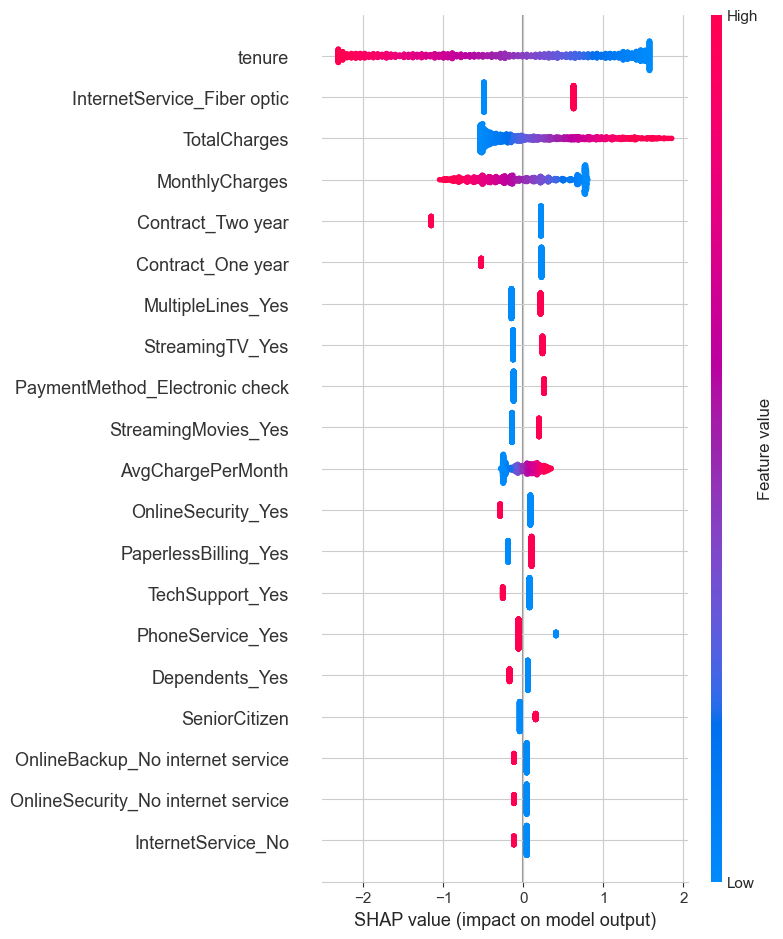

In [104]:
st.subheader("Model Explanation (SHAP)")

explainer = shap.Explainer(model, model_features)

shap_values = explainer(model_features)

fig = plt.figure()

shap.summary_plot(shap_values, model_features, show=False)

st.pyplot(fig)


SHAP values measure **how each feature contributes to the prediction made by the model**.

For example, SHAP analysis may reveal that churn is influenced by:

- Contract type
- Monthly charges
- Customer tenure

### Business Interpretation of SHAP

The SHAP plot identifies the **most important drivers of churn**.

| Feature | Impact |
|--------|-------|
| Contract Type | Strong driver of churn |
| Monthly Charges | Higher prices increase churn risk |
| Tenure | Long-term customers are less likely to churn |

### Strategic Business Impact

This system enables organizations to move from **reactive churn management** to **proactive retention strategies**.

### Key Benefits

- Early identification of at-risk customers  
- Better understanding of churn drivers  
- Targeted retention campaigns  
- Reduced revenue loss  


## 🟢 1️⃣ Dashboard Interface Design

To improve usability and create a professional SaaS-style interface, the Streamlit application is structured into multiple sections:

• Executive KPI Overview  
• Customer Dataset Preview  
• Churn Prediction Results  
• Risk Distribution Visualization  
• Model Explainability (SHAP)  
• Business Retention Insights  

This structure allows both technical and non-technical stakeholders to easily understand the churn analysis results.

In [107]:
total_customers = len(results)
high_risk = (results["Risk Level"] == "High Risk").sum()
medium_risk = (results["Risk Level"] == "Medium Risk").sum()
low_risk = (results["Risk Level"] == "Low Risk").sum()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Customers", total_customers)
col2.metric("High Risk Customers", high_risk)
col3.metric("Medium Risk Customers", medium_risk)
col4.metric("Low Risk Customers", low_risk)

2026-03-06 19:58:42.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.277 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.282 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:58:42.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

### Executive KPI Overview

Key performance indicators provide a quick overview of churn risk across the customer base.

Displayed metrics include:

• Total number of analyzed customers  
• Number of high-risk churn customers  
• Medium-risk customers  
• Low-risk customers  

Business Value

This allows decision-makers to quickly assess the overall risk exposure without analyzing detailed datasets.

In [109]:
import matplotlib.pyplot as plt

risk_counts = results["Risk Level"].value_counts()

fig, ax = plt.subplots()

ax.bar(risk_counts.index, risk_counts.values)

ax.set_title("Customer Churn Risk Distribution")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Number of Customers")

st.pyplot(fig)

2026-03-06 19:59:50.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:59:51.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 19:59:51.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

### Customer Churn Risk Distribution

A visual representation of the distribution of customers across risk categories.

Risk categories include:

• Low Risk  
• Medium Risk  
• High Risk  

Business Value

Understanding the distribution of churn risk allows companies to allocate retention resources effectively.

In [110]:
st.subheader("Customer Churn Prediction Results")

st.dataframe(
    results[[
        "Churn Probability",
        "Risk Level"
    ] + list(results.columns[:5])]
)

2026-03-06 20:01:02.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:02.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:02.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:02.245 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

### Customer Churn Prediction Results

The table displays the prediction results for each customer.

Displayed information includes:

• Customer attributes  
• Predicted churn probability  
• Assigned risk level  

Business Value

This enables marketing and customer success teams to identify individual customers that require retention interventions.

2026-03-06 20:01:54.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:54.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


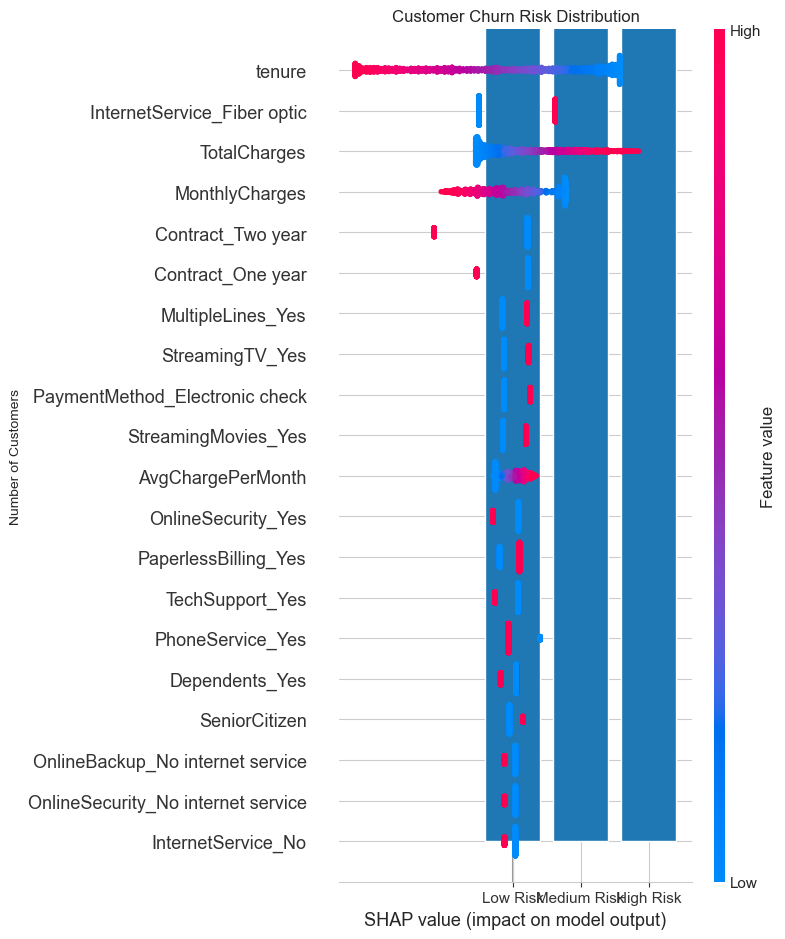

2026-03-06 20:01:55.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:55.259 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:55.260 
Calling `st.pyplot()` without providing a figure argument has been deprecated
and will be removed in a later version as it requires the use of Matplotlib's
global figure object, which is not thread-safe.

To future-proof this code, you should pass in a figure as shown below:

```python
fig, ax = plt.subplots()
ax.scatter([1, 2, 3], [1, 2, 3])
# other plotting actions...
st.pyplot(fig)
```

If you have a specific use case that requires this functionality, please let us
know via [issue on Github](https://github.com/streamlit/streamlit/issues).

2026-03-06 20:01:55.260 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:01:55.349 Thread 'MainThread': mis

DeltaGenerator()

In [111]:
st.subheader("Model Explainability (SHAP)")

explainer = shap.Explainer(model, model_features)

shap_values = explainer(model_features)

shap.summary_plot(shap_values, model_features)

st.pyplot()

### Model Explainability Using SHAP

SHAP (SHapley Additive exPlanations) is used to explain how each feature contributes to churn predictions.

The SHAP summary plot highlights:

• Features that increase churn probability  
• Features that reduce churn probability  
• The overall importance of each variable

Business Value

Explainable AI builds trust with stakeholders by showing why the model predicts churn.

In [112]:
st.subheader("Retention Strategy Insights")

st.write("""
Recommended Actions:

High Risk Customers:
• Offer retention discounts
• Provide personalized support

Medium Risk Customers:
• Offer loyalty rewards
• Improve engagement

Low Risk Customers:
• Maintain service quality
""")

2026-03-06 20:03:23.615 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:03:23.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:03:23.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 20:03:23.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


### Strategic Retention Recommendations

Based on churn predictions, organizations can implement targeted retention strategies.

Risk Level | Recommended Action
-----------|-------------------
High Risk | Immediate retention intervention
Medium Risk | Loyalty incentives and engagement programs
Low Risk | Maintain strong customer experience

Business Value

This allows organizations to shift from reactive churn management to proactive retention strategies.

In [113]:
!pip install streamlit shap pandas numpy matplotlib joblib

In [ ]:
!streamlit run app.py